
**Testing the Unet with good images and excessprint defect images**

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!unzip /content/gdrive/MyDrive/U-Net/test_images.zip -d /content/gdrive/MyDrive/U-Net

In [1]:
import os
os.chdir('/content/gdrive/MyDrive/U-Net')
os.getcwd()

'/content/gdrive/MyDrive/U-Net'

In [2]:
import tensorflow as tf
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Model
import cv2
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from keras.utils import to_categorical
from tqdm import tqdm
from glob import glob
from albumentations import RandomRotate90, GridDistortion, HorizontalFlip, VerticalFlip, Compose

In [3]:
def augment_data(images, masks, augment=True):
    H = 256
    W = 256
    x = cv2.imread(images)
    y = cv2.imread(masks)
    if augment == True:
        # Create an albumentations augmentation pipeline
        augmentation_pipeline = Compose([
            RandomRotate90(p=1.0),
            HorizontalFlip(p=1.0),
            VerticalFlip(p=1.0)
        ])

        # Augment the image and mask
        augmented = augmentation_pipeline(image=x, mask=y)
        x2 = augmented['image']
        y2 = augmented['mask']

        # Save the augmented images and masks
        save_images = [x, x2]
        save_masks =  [y, y2]

    return save_images, save_masks

Reading the file path of training images

In [4]:
path = '/content/gdrive/MyDrive/U-Net/train_images'
path1 = '/content/gdrive/MyDrive/U-Net/train_labels'
files = sorted(os.listdir(path))



In [5]:
train_images = []
train_labels = []
for each_image in files:
  if each_image.endswith(".bmp"):
    full_path = os.path.join(path, each_image)
    lb_path = os.path.join(path1,each_image)
    image_aug, lb_img = augment_data(full_path, lb_path,augment=True)
    for i,m in zip(image_aug,lb_img):
      image = cv2.resize(i, (256, 256), interpolation=cv2.INTER_AREA)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
      train_images.append(image)

      image = cv2.resize(m, (256, 256), interpolation=cv2.INTER_AREA)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
      train_labels.append(image)

train_images = np.array(train_images)
print(train_images.shape)

train_labels = np.array(train_labels)
print(train_labels.shape)

(1920, 256, 256)
(1920, 256, 256)


Reading the file path of training labels

In [53]:
print(np.unique(train_labels))

[0 1 2]


Reading the file path of test images

In [6]:
path2 = '/content/gdrive/MyDrive/U-Net/test_images/'
path3 = '/content/gdrive/MyDrive/U-Net/test_labels/'
files2 = sorted(os.listdir(path2))
print(files2)

['1 (14).bmp', '1 (4).bmp', '1 (9).bmp', '184 (13).bmp', '184 (18).bmp', '184 (23).bmp', '184 (3).bmp', '184 (8).bmp', '25 (12).bmp', '25 (2).bmp', '25 (7).bmp', '277 (12).bmp', '277 (17).bmp', '277 (2).bmp', '277 (22).bmp', '277 (7).bmp', '3 (4).bmp', '3 (9).bmp', '307 (12).bmp', '307 (17).bmp', '307 (2).bmp', '307 (22).bmp', '307 (27).bmp', '307 (7).bmp', '39 (10).bmp', '39 (5).bmp', '739 (10).bmp', '739 (15).bmp', '739 (20).bmp', '739 (5).bmp', '811 (1).bmp', '811 (11).bmp', '811 (16).bmp', '811 (21).bmp', '811 (26).bmp', '811 (6).bmp', '996 (13).bmp', '996 (18).bmp', '996 (3).bmp', '996 (8).bmp', 'Img_ (10).bmp', 'Img_ (100).bmp', 'Img_ (1000).bmp', 'Img_ (105).bmp', 'Img_ (110).bmp', 'Img_ (115).bmp', 'Img_ (120).bmp', 'Img_ (125).bmp', 'Img_ (130).bmp', 'Img_ (135).bmp', 'Img_ (140).bmp', 'Img_ (145).bmp', 'Img_ (15).bmp', 'Img_ (150).bmp', 'Img_ (155).bmp', 'Img_ (160).bmp', 'Img_ (165).bmp', 'Img_ (170).bmp', 'Img_ (175).bmp', 'Img_ (180).bmp', 'Img_ (185).bmp', 'Img_ (190).bmp

In [7]:
test_images = []
test_labels = []
for each_image in files2:
  if each_image.endswith(".bmp"):
    full_path = os.path.join(path2, each_image)
    lb_path = os.path.join(path3,each_image)
    image_aug, lb_img = augment_data(full_path, lb_path,augment=True)
    for i,m in zip(image_aug,lb_img):
      image = cv2.resize(i, (256, 256), interpolation=cv2.INTER_AREA)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
      test_images.append(image)

      image = cv2.resize(m, (256, 256), interpolation=cv2.INTER_AREA)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
      test_labels.append(image)

test_images = np.array(test_images)
print(test_images.shape)

test_labels = np.array(test_labels)
print(test_labels.shape)

(480, 256, 256)
(480, 256, 256)


Reading the file path of test labels

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[0 1 2]


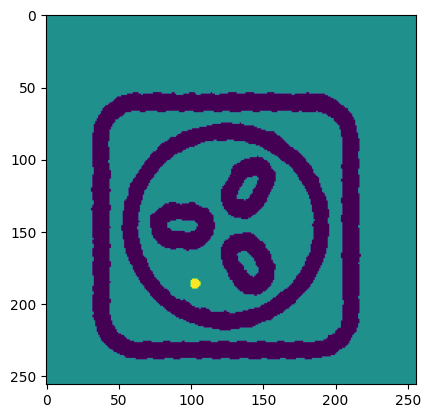

In [57]:
img = test_labels[3]
plt.imshow(img)
print(img)
print(np.unique(test_labels))

Normalization

In [8]:
x_train = train_images.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 256,256,1))
x_test = test_images.astype('float32') / 255.
x_test = x_test.reshape((len(x_test), 256,256,1))
                  

In [9]:
y_train = train_labels.astype('float32') #/ 255.
y_train = y_train.reshape((len(y_train), 256,256,1))
y_test = test_labels.astype('float32') #/ 255.
y_test = y_test.reshape((len(y_test), 256,256,1))
                  

In [10]:
print(y_train.shape)

(1920, 256, 256, 1)


In [11]:
img_width = 256
img_height = 256
img_channels = 1
n_classes=3

converting the each output pixel into 3clases for segmentation 

In [12]:
y_train_cat = to_categorical(y_train,num_classes=n_classes)
print(y_train_cat.shape)

(1920, 256, 256, 3)


In [13]:
print(y_test.shape)

(480, 256, 256, 1)


In [14]:
y_test_cat = to_categorical(y_test,num_classes=n_classes)

In [15]:
print(y_test_cat.shape)

(480, 256, 256, 3)


In [16]:
print(np.unique(y_train))

[0. 1. 2.]


 Building the multiclass UNet model

In [17]:
def segmentation_model(n_classes=3, IMG_HEIGHT=256, IMG_WIDTH=256, IMG_CHANNELS=1):
#Build the model
    s = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    #s = Lambda(lambda x: x / 255)(inputs)   #No need for this if we normalize our inputs beforehand
    input= s

    #Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(input)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
     
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
     
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)
     
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    #Expansive path 
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
     
    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
     
    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
     
    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (1, 1), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
     
    outputs = Conv2D(n_classes, (1, 1), activation='softmax')(c9)
     
    segmentation_model = Model(inputs=[s], outputs=[outputs])
    
    return segmentation_model


Model compilation

In [18]:
# for 2 class segmentation, loss is binary_crossentropy
model = segmentation_model(n_classes=3, IMG_HEIGHT=256, IMG_WIDTH=256, IMG_CHANNELS=1)
optimizer = tf.keras.optimizers.Adam(0.0001)
model.compile(optimizer= optimizer,loss='categorical_crossentropy',metrics=['accuracy']) 
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 16  160         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 dropout (Dropout)              (None, 256, 256, 16  0           ['conv2d[0][0]']                 
                                )                                                             

In [19]:
from keras.utils.vis_utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [20]:
#Model checkpoint
lr_reducer = ReduceLROnPlateau(monitor="val_loss",
                               factor=0.8,
                               patience=5,
                               verbose=1,
                               mode='min',
                               min_delta=0.0001,
                               cooldown=3,
                               min_lr=1e-6) #0.000001

In [21]:
#Model checkpoint
checkpoint = tf.keras.callbacks.ModelCheckpoint('model_for_printedimages',verbose = 1, save_best_only=True)
callbacks = [tf.keras.callbacks.EarlyStopping(patience=2,monitor='val_loss'),lr_reducer]

Training the model

In [22]:
hist=model.fit(x_train, y_train_cat,
                epochs=50,
                batch_size=16,
                shuffle=True,
                #class_weights=class_weights,
                validation_data=(x_test, y_test_cat) )

Epoch 1/50
120/120 [==============================] - 44s 182ms/step - loss: 0.5069 - accuracy: 0.7774 - val_loss: 0.1977 - val_accuracy: 0.9199
Epoch 2/50
120/120 [==============================] - 21s 173ms/step - loss: 0.0813 - accuracy: 0.9722 - val_loss: 0.1088 - val_accuracy: 0.9566
Epoch 3/50
120/120 [==============================] - 21s 175ms/step - loss: 0.0538 - accuracy: 0.9819 - val_loss: 0.0881 - val_accuracy: 0.9646
Epoch 4/50
120/120 [==============================] - 21s 175ms/step - loss: 0.0453 - accuracy: 0.9847 - val_loss: 0.0801 - val_accuracy: 0.9677
Epoch 5/50
120/120 [==============================] - 21s 177ms/step - loss: 0.0403 - accuracy: 0.9863 - val_loss: 0.0652 - val_accuracy: 0.9729
Epoch 6/50
120/120 [==============================] - 22s 180ms/step - loss: 0.0368 - accuracy: 0.9874 - val_loss: 0.0671 - val_accuracy: 0.9726
Epoch 7/50
120/120 [==============================] - 21s 179ms/step - loss: 0.0335 - accuracy: 0.9883 - val_loss: 0.0587 - val_ac

plotting of training and validation loss wrt epochs

In [23]:
model.save('unet_print.hdf5')  # saving the model

In [24]:
model.save_weights('unet_print_weights.h5') # saving the model weights

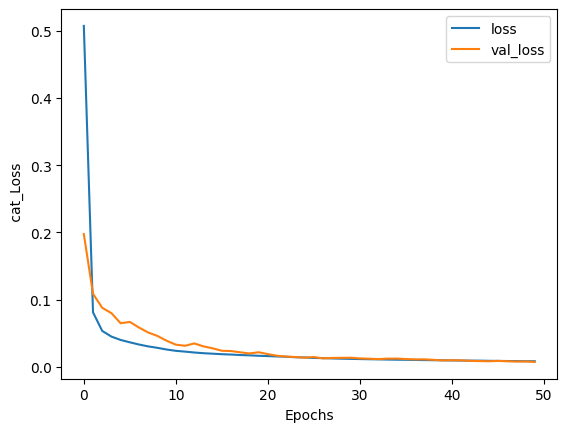

In [25]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel(' cat_Loss')
plt.legend(['loss', 'val_loss'])
plt.show()

evaluation of model

In [ ]:
# acc = hist.history['accuracy']
# val_acc = hist.history['val_accuracy']

In [26]:
_, acc = model.evaluate(x_test, y_test_cat)
print("Accuracy is = ", (acc * 100.0), "%")

15/15 [==============================] - 4s 72ms/step - loss: 0.0077 - accuracy: 0.9969
Accuracy is =  99.68739151954651 %


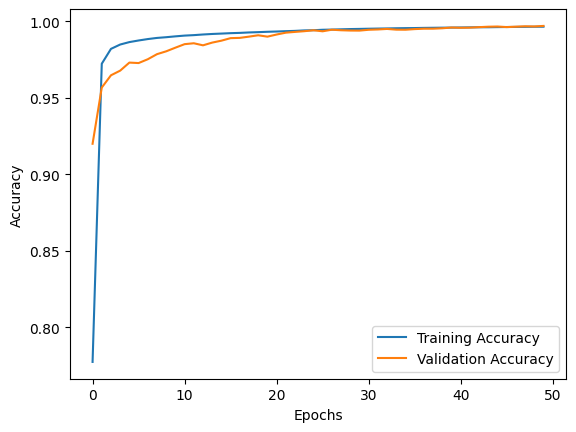

In [27]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

In [28]:
#IOU
y_pred=model.predict(x_test)
y_pred_argmax=np.argmax(y_pred, axis=3)

15/15 [==============================] - 1s 66ms/step


In [29]:
#Using built in keras function
from keras.metrics import MeanIoU
n_classes = 3
IOU_keras = MeanIoU(num_classes=n_classes)  
IOU_keras.update_state(y_test[:,:,:,0], y_pred_argmax)
print("Mean IoU =", IOU_keras.result().numpy())

Mean IoU = 0.91624546


In [30]:
model.load_weights('unet_print_weights.h5')

In [31]:
#To calculate I0U for each class...
values = np.array(IOU_keras.get_weights()).reshape(n_classes, n_classes)
print(values)
class1_IoU = values[0,0]/(values[0,0] + values[0,1] + values[0,2] + values[1,0]+ values[2,0])
class2_IoU = values[1,1]/(values[1,1] + values[1,0] + values[1,2] + values[0,1]+ values[2,1])
class3_IoU = values[2,2]/(values[2,2] + values[2,0] + values[2,1] + values[0,2]+ values[1,2])


[[7.4851810e+06 7.3405000e+04 2.3040000e+03]
 [1.8477000e+04 1.6777216e+07 3.3300000e+02]
 [2.9590000e+03 8.5700000e+02 2.1250000e+04]]


In [32]:
print("IoU for class1 is: ", class1_IoU)
print("IoU for class2 is: ", class2_IoU)
print("IoU for class3 is: ", class3_IoU)

IoU for class1 is:  0.987188
IoU for class2 is:  0.9944833
IoU for class3 is:  0.7670649


Plotting the segmented image by network

In [33]:
import random
test_img_number = random.randint(0, len(x_test))
test_img = x_test[test_img_number]
ground_truth=y_test[test_img_number]
test_img_norm=test_img[:,:,0][:,:,None]
test_img_input=np.expand_dims(test_img_norm, 0)
prediction = (model.predict(test_img_input))
predicted_img=np.argmax(prediction, axis=3)[0,:,:]

1/1 [==============================] - 1s 857ms/step


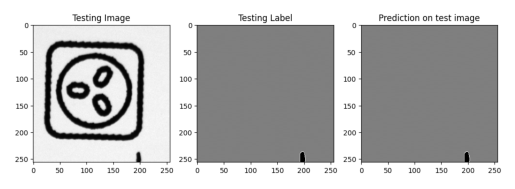

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,0], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth[:,:,0], cmap='gray')
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(predicted_img, cmap='gray')
plt.show()